# Exploratory Data Analysis

In [34]:
!pip install gensim

## Data Selection

In [35]:
import re
from gensim.utils import simple_preprocess

data_path = "data/AllCombined.txt"

print("Dataset path:", data_path)

Dataset path: data/AllCombined.txt


## Corpus Analysis

In [36]:
# Let's look at the raw text
with open(data_path, 'r', encoding='utf-8') as f:
    for i in range(5):
        print(f"--- Document {i+1} ---")
        print(f.readline()[:500])

--- Document 1 ---


--- Document 2 ---
April

--- Document 3 ---


--- Document 4 ---
April (Apr.) is the fourth month of the year in the Julian and Gregorian calendars, and comes between March and May. It is one of four months to have 30 days.

--- Document 5 ---




In [37]:
cnt = 1
with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            print(cnt, ".  ", "RAW:", line[:200])
            sentences = re.split(r'[.!?]\s+', line)
            print("SPLIT:", sentences[:3])

            for sent in sentences[:3]:
                tokens = simple_preprocess(sent)
                print("TOKENS:", tokens)
            cnt += 1
            if cnt > 3:
                break

1 .   RAW: April

SPLIT: ['April\n']
TOKENS: ['april']
2 .   RAW: April (Apr.) is the fourth month of the year in the Julian and Gregorian calendars, and comes between March and May. It is one of four months to have 30 days.

SPLIT: ['April (Apr.) is the fourth month of the year in the Julian and Gregorian calendars, and comes between March and May', 'It is one of four months to have 30 days', '']
TOKENS: ['april', 'apr', 'is', 'the', 'fourth', 'month', 'of', 'the', 'year', 'in', 'the', 'julian', 'and', 'gregorian', 'calendars', 'and', 'comes', 'between', 'march', 'and', 'may']
TOKENS: ['it', 'is', 'one', 'of', 'four', 'months', 'to', 'have', 'days']
TOKENS: []
3 .   RAW: April always begins on the same day of the week as July, and additionally, January in leap years. April always ends on the same day of the week as December.

SPLIT: ['April always begins on the same day of the week as July, and additionally, January in leap years', 'April always ends on the same day of the week as Dec

In [38]:
from collections import Counter
from tqdm import tqdm

total_sentences = 0
total_tokens = 0
sentence_lengths = []
word_counts = Counter()

with open(data_path, 'r', encoding='utf-8') as f:
    for line in tqdm(f):
        sentences = re.split(r'[.!?]\s+', line)

        for sent in sentences:
            tokens = simple_preprocess(sent)

            if len(tokens) > 2:
                total_sentences += 1
                total_tokens += len(tokens)
                sentence_lengths.append(len(tokens))
                word_counts.update(tokens)

print("Total sentences:", total_sentences)
print("Total tokens:", total_tokens)
print("Vocabulary size (raw):", len(word_counts))

2052699it [01:02, 32816.57it/s]

Total sentences: 2041000
Total tokens: 27584099
Vocabulary size (raw): 396064


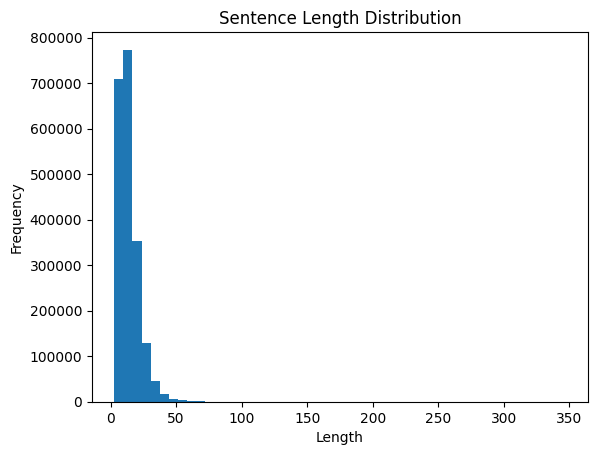

In [39]:
import matplotlib.pyplot as plt

plt.hist(sentence_lengths, bins=50)
plt.title("Sentence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

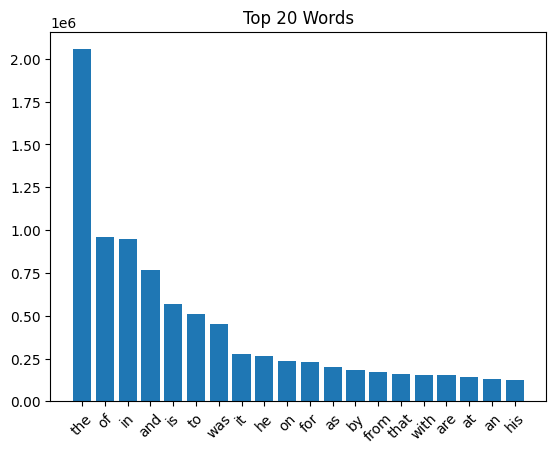

In [40]:
top_words = word_counts.most_common(20)

words = [w for w, _ in top_words]
counts = [c for _, c in top_words]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.show()

## Analysis of future restrictions

In [41]:
empty_lines = 0
non_empty_lines = 0

empty_sentences = 0
valid_sentences = 0

with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            empty_lines += 1
            continue
        else:
            non_empty_lines += 1

        sentences = re.split(r'[.!?]\s+', line)

        for sent in sentences:
            tokens = simple_preprocess(sent)

            if len(tokens) == 0:
                empty_sentences += 1
            else:
                valid_sentences += 1

print("Empty lines:", empty_lines)
print("Non-empty lines:", non_empty_lines)
print("Empty sentences:", empty_sentences)
print("Valid sentences:", valid_sentences)

Empty lines: 1075364
Non-empty lines: 977335
Empty sentences: 662282
Valid sentences: 2257777


In [42]:
short_sentences = 0
long_sentences = 0

with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        sentences = re.split(r'[.!?]\s+', line)

        for sent in sentences:
            tokens = simple_preprocess(sent)

            if len(tokens) < 3:
                short_sentences += 1
            else:
                long_sentences += 1

print("Short sentences (<3 tokens):", short_sentences)
print("Valid sentences (>=3 tokens):", long_sentences)

Short sentences (<3 tokens): 1954423
Valid sentences (>=3 tokens): 2041000


In [43]:
low_freq_words = 0
high_freq_words = 0

for word, count in word_counts.items():
    if count < 5:
        low_freq_words += 1
    else:
        high_freq_words += 1

print("Words with freq < 5:", low_freq_words)
print("Words with freq >= 5:", high_freq_words)

Words with freq < 5: 290119
Words with freq >= 5: 105945


In [44]:
total_vocab = len(word_counts)
total_sentences = short_sentences + long_sentences

print("Percentage of empty lines:", empty_lines / (empty_lines + non_empty_lines))
print("Percentage of short sentences (<3):", short_sentences / total_sentences)
print("Percentage of rare words (<5):", low_freq_words / total_vocab)

Percentage of empty lines: 0.5238780746714448
Percentage of short sentences (<3): 0.4891654775977412
Percentage of rare words (<5): 0.7325053526702755


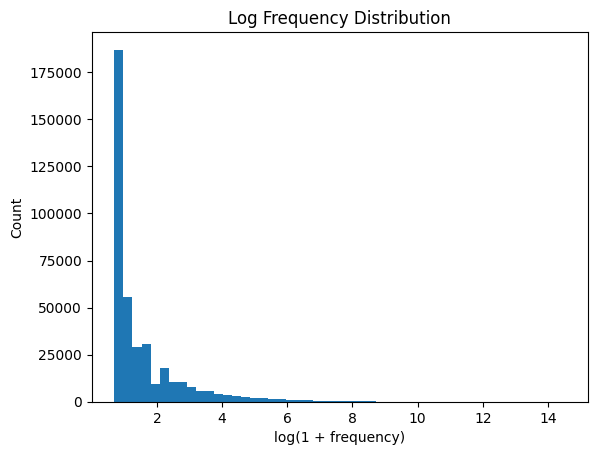

In [45]:
import numpy as np

freqs = list(word_counts.values())

plt.hist(np.log1p(freqs), bins=50)
plt.title("Log Frequency Distribution")
plt.xlabel("log(1 + frequency)")
plt.ylabel("Count")
plt.show()

### Data Insights

- 49% of sentences are shorter than 3 tokens and will be removed.
- 52% of lines in the dataset are empty.
- A large portion of vocabulary (≈73%) consists of rare words (<5 occurrences).

This confirms that:
- Filtering short sentences is necessary to ensure meaningful context.
- min_count=5 removes a significant amount of noise but may reduce rare word representation.

# Data Preparation

## Vocabulary & Statistics

In [46]:
MIN_COUNT = 5

filtered_vocab = {word: count for word, count in word_counts.items() if count >= MIN_COUNT}

print("Vocabulary size after min_count:", len(filtered_vocab))

Vocabulary size after min_count: 105945


- Rare words are partially filtered by min_count=5.
- This may reduce the observable advantage of Skip-gram on rare words.
- However, this ensures more stable training and fair comparison.

In [47]:
import numpy as np

sorted_words = sorted(filtered_vocab.items(), key=lambda x: x[1], reverse=True)

words_only = [w for w, _ in sorted_words]

top_k = int(0.1 * len(words_only))   # top 10%
bottom_k = int(0.1 * len(words_only))  # bottom 10%

frequent_words = set(words_only[:top_k])
rare_words = set(words_only[-bottom_k:])

print("Frequent words:", len(frequent_words))
print("Rare words:", len(rare_words))

Frequent words: 10594
Rare words: 10594


In [48]:
class FinalWikiSentences:
    def __init__(self, filepath, vocab):
        self.filepath = filepath
        self.vocab = set(vocab)

    def __iter__(self):
        with open(self.filepath, 'r', encoding='utf-8') as f:
            for line in f:
                sentences = re.split(r'[.!?]\s+', line)

                for sent in sentences:
                    tokens = simple_preprocess(sent)

                    if len(tokens) > 2:
                        tokens = [t for t in tokens if t in self.vocab]

                        if len(tokens) > 2:
                            yield tokens

sentences = FinalWikiSentences(data_path, filtered_vocab.keys())

print("Final dataset ready")

Final dataset ready


In [49]:
final_sent_count = 0
final_token_count = 0

for sent in sentences:
    final_sent_count += 1
    final_token_count += len(sent)

print("Final sentences:", final_sent_count)
print("Final tokens:", final_token_count)

Final sentences: 2027259
Final tokens: 27099267


## Dataset Summary

- Source: Simple English Wikipedia
- Total sentences: 2027259
- Total tokens: 27099267
- Vocabulary size (raw): 396064
- Vocabulary size (min_count=5): 105945

### Preprocessing
- Tokenization: simple_preprocess (Gensim)
- Lowercasing: yes
- Min token length: >2 words per sentence
- Rare words removed: min_count = 5
- Stopwords: kept

### Frequency Split
- Frequent words: top 10%
- Rare words: bottom 10%

### Notes
- Dataset is relatively simple (Simple English), which may reduce vocabulary richness.
- This may impact performance differences between CBOW and Skip-gram, especially for rare words.

## Saving files

In [50]:
processed_data = list(sentences)

print("Saved sentences:", len(processed_data))

import pickle
with open("data/processed_sentences.pkl", "wb") as f:
    pickle.dump(processed_data, f)

Saved sentences: 2027259


In [51]:
with open("data/frequent_words.pkl", "wb") as f:
    pickle.dump(frequent_words, f)

with open("data/rare_words.pkl", "wb") as f:
    pickle.dump(rare_words, f)